In [ ]:
# Customer Churn Prediction and Technician RAG Workflow

## Project Overview

This project focuses on predicting customer churn using machine learning
and defining a Technician RAG (Retrieval-Augmented Generation) workflow.

The customer churn analysis identifies customers who are likely to leave
a service based on their demographic, account, and service-related
information.

The Technician RAG workflow is designed to help technicians retrieve
relevant technical knowledge for solving customer issues.

In [ ]:
# Import required libraries for data analysis and visualization

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import libraries required for machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Load the IBM Telco Customer Churn dataset

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset loaded successfully!
Number of rows: 7043
Number of columns: 21


In [ ]:
# Display the first five rows of the dataset

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
# Check missing values in each column

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [ ]:
# Display statistical summary of numerical columns

df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
# Check the number of customers who churned and did not churn

print("Customer Churn Distribution:")
print(df["Churn"].value_counts())

Customer Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


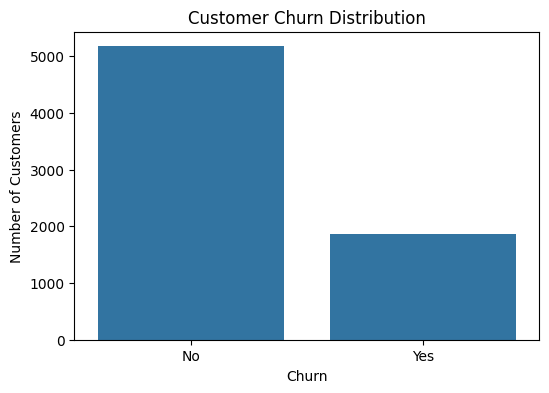

In [ ]:
# Visualize customer churn distribution

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
# Check the data types of all columns

print("Data types of each column:")
print(df.dtypes)

Data types of each column:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [ ]:
# Display the total number of customers

total_customers = len(df)

print("Total number of customers:", total_customers)

Total number of customers: 7043


In [ ]:
# Display the number of unique values in each column

print("Unique values in each column:")
print(df.nunique())

Unique values in each column:
customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64


In [ ]:
# Convert TotalCharges into numeric format
# Invalid or empty values will be converted to NaN

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Check missing values after conversion

print("Missing values after converting TotalCharges:")
print(df.isnull().sum())

Missing values after converting TotalCharges:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [ ]:
# Remove rows containing missing values

df = df.dropna()

print("Dataset shape after removing missing values:", df.shape)

Dataset shape after removing missing values: (7032, 21)


In [ ]:
# Calculate the percentage of customers who churned

churn_percentage = df["Churn"].value_counts(normalize=True) * 100

print("Customer Churn Percentage:")
print(churn_percentage)

Customer Churn Percentage:
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


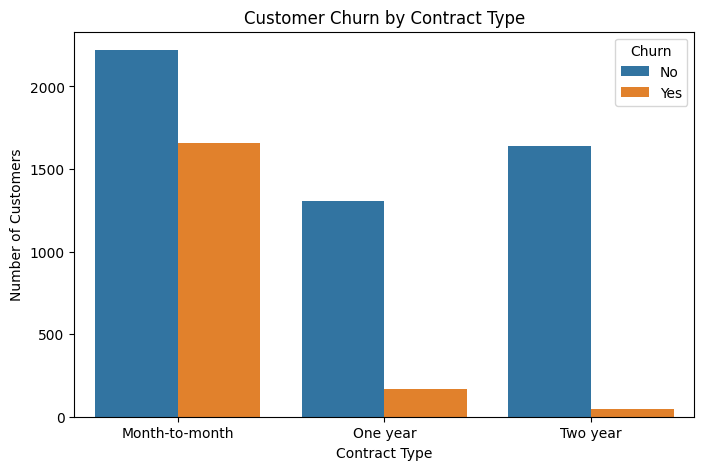

In [ ]:
# Analyze customer churn based on contract type

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Contract", hue="Churn")

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

### Analysis

The contract type is an important factor in customer churn.
Customers with different contract durations show different churn patterns.
Short-term contracts may have a higher tendency toward churn compared with
long-term contracts.

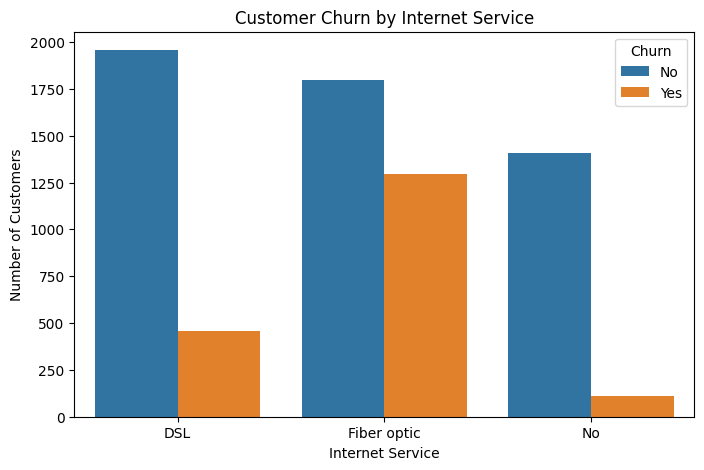

In [ ]:
# Analyze customer churn based on internet service type

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="InternetService", hue="Churn")

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

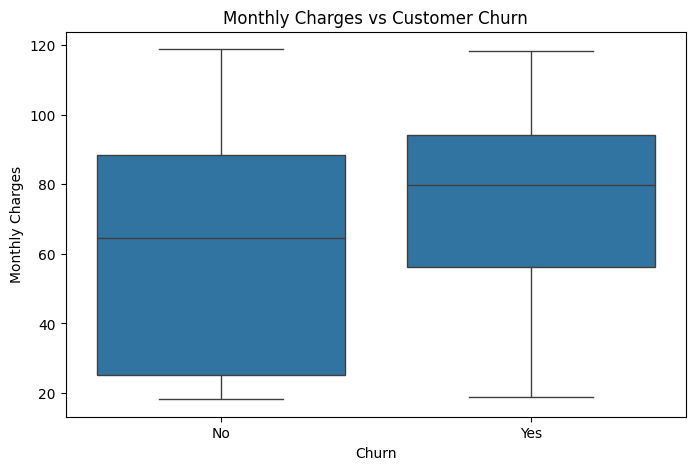

In [ ]:
# Compare monthly charges between customers who churned and those who stayed

plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

plt.title("Monthly Charges vs Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

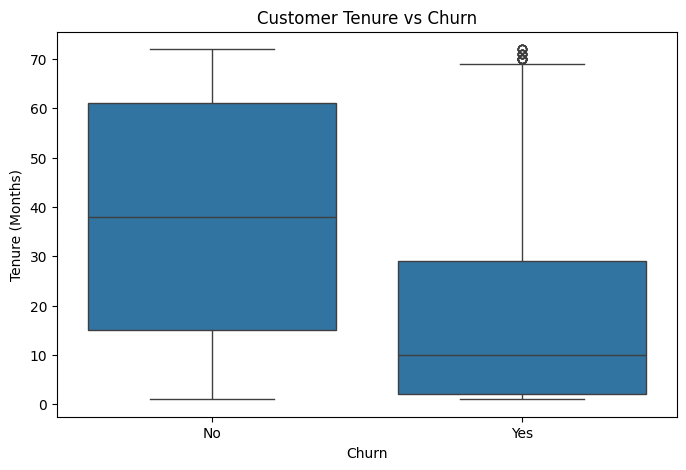

In [ ]:
# Compare customer tenure with churn status

plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Churn", y="tenure")

plt.title("Customer Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

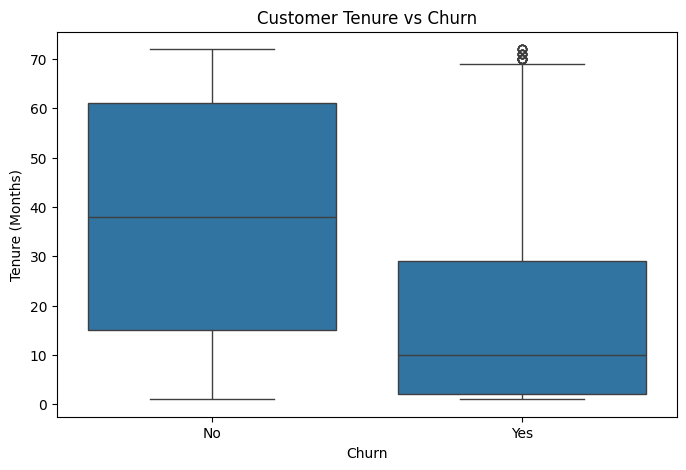

In [ ]:
# Compare customer tenure with churn status

plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Churn", y="tenure")

plt.title("Customer Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

In [ ]:
# Convert the target variable Churn into numerical values

df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

print("Churn values after encoding:")
print(df["Churn"].value_counts())

Churn values after encoding:
Churn
0    5163
1    1869
Name: count, dtype: int64


In [ ]:
# Convert categorical columns into numerical values using one-hot encoding

df_encoded = pd.get_dummies(df, drop_first=True)

print("Categorical variables encoded successfully!")
print("New dataset shape:", df_encoded.shape)

Categorical variables encoded successfully!
New dataset shape: (7032, 7062)


In [ ]:
# Separate input features (X) and target variable (y)

X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7032, 7061)
Target shape: (7032,)


In [ ]:
# Split the dataset into training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5625, 7061)
Testing data: (1407, 7061)


In [ ]:
# Create a faster Logistic Regression model

model = LogisticRegression(
    max_iter=200,
    solver="liblinear",
    random_state=42
)

# Train the model using the training data

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [ ]:
# Generate churn predictions for the test data

y_pred = model.predict(X_test)

print("Churn predictions generated successfully!")
print("First 10 predictions:", y_pred[:10])

Churn predictions generated successfully!
First 10 predictions: [0 1 0 0 0 0 0 0 1 0]


In [ ]:
# Calculate model accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 79.74 %


In [ ]:
# Display the classification report

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1033
           1       0.64      0.56      0.59       374

    accuracy                           0.80      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.80      0.79      1407



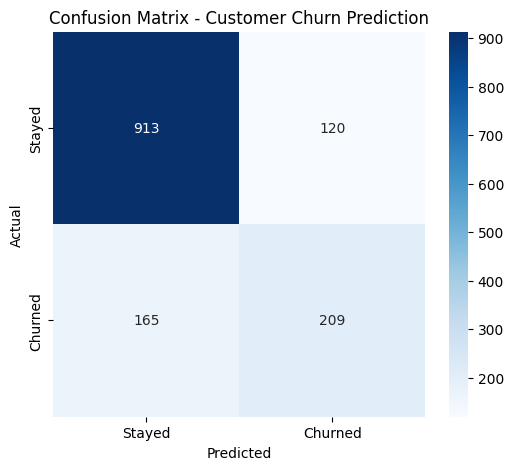

In [ ]:
# Generate and display the confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed", "Churned"],
    yticklabels=["Stayed", "Churned"]
)

plt.title("Confusion Matrix - Customer Churn Prediction")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
# Technician RAG Workflow

The Technician RAG workflow helps technicians retrieve relevant technical
information based on a customer's issue.

The workflow consists of:

Customer Issue → Query Processing → Knowledge Base → Relevant Information
→ Technician Response

In [ ]:
# Create a small knowledge base containing common customer technical issues

technician_knowledge = [
    {
        "issue": "internet connection problem",
        "solution": "Check the router power connection, restart the router, and verify the network cable."
    },
    {
        "issue": "slow internet",
        "solution": "Check network speed, restart the router, reduce connected devices, and inspect signal strength."
    },
    {
        "issue": "wifi not working",
        "solution": "Restart the Wi-Fi router, check Wi-Fi settings, and reconnect the customer device."
    },
    {
        "issue": "billing problem",
        "solution": "Verify the customer's billing details, payment status, and recent transactions."
    },
    {
        "issue": "service disconnected",
        "solution": "Check account status, payment status, service availability, and connection settings."
    }
]

print("Technician knowledge base created successfully!")
print("Number of knowledge entries:", len(technician_knowledge))

Technician knowledge base created successfully!
Number of knowledge entries: 5


In [ ]:
# Display the technician knowledge base

knowledge_df = pd.DataFrame(technician_knowledge)

knowledge_df

,issue,solution
0,internet connection problem,"Check the router power connection, restart the..."
1,slow internet,"Check network speed, restart the router, reduc..."
2,wifi not working,"Restart the Wi-Fi router, check Wi-Fi settings..."
3,billing problem,"Verify the customer's billing details, payment..."
4,service disconnected,"Check account status, payment status, service ..."


In [ ]:
# Define a function to retrieve relevant information from the knowledge base

def retrieve_solution(customer_query):

    customer_query = customer_query.lower()

    for item in technician_knowledge:

        if any(word in customer_query for word in item["issue"].split()):
            return item["solution"]

    return "No relevant solution found in the technician knowledge base."

In [ ]:
# Test the retrieval system with a customer issue

customer_query = "My internet connection is not working"

retrieved_solution = retrieve_solution(customer_query)

print("Customer Query:")
print(customer_query)

print("\nRetrieved Technician Information:")
print(retrieved_solution)

Customer Query:
My internet connection is not working

Retrieved Technician Information:
Check the router power connection, restart the router, and verify the network cable.


In [ ]:
# Test the retrieval system with another customer issue

customer_query = "My internet is very slow"

retrieved_solution = retrieve_solution(customer_query)

print("Customer Query:")
print(customer_query)

print("\nRetrieved Technician Information:")
print(retrieved_solution)

Customer Query:
My internet is very slow

Retrieved Technician Information:
Check the router power connection, restart the router, and verify the network cable.


In [ ]:
## Technician RAG Workflow

1. Customer submits a technical issue.
2. The customer query is processed.
3. The system searches the technician knowledge base.
4. Relevant technical information is retrieved.
5. The retrieved information is provided to the technician.
6. The technician uses the retrieved information to assist the customer.

### Workflow

Customer Issue
       ↓
Query Processing
       ↓
Knowledge Base Search
       ↓
Relevant Information Retrieval
       ↓
Technician
       ↓
Customer Support

# Connecting Churn Indicators with Technical Troubleshooting Information

This section connects important customer churn indicators with relevant
technical troubleshooting information.

The purpose is to help technicians understand potential churn-related
signals and provide appropriate troubleshooting guidance.

In [1]:
# Identify important customer attributes related to churn analysis

churn_indicators = [
    "Contract",
    "tenure",
    "MonthlyCharges",
    "InternetService",
    "TechSupport"
]

print("Churn indicators considered in this project:")

for indicator in churn_indicators:
    print("-", indicator)

Churn indicators considered in this project:
- Contract
- tenure
- MonthlyCharges
- InternetService
- TechSupport


In [2]:
# Connect churn indicators with relevant technical troubleshooting information

troubleshooting_map = {
    "InternetService": {
        "indicator": "Internet service type",
        "troubleshooting": "Check internet connection, router status, network speed, and signal strength."
    },

    "TechSupport": {
        "indicator": "Technical support status",
        "troubleshooting": "Check unresolved technical issues and provide appropriate troubleshooting assistance."
    },

    "tenure": {
        "indicator": "Short customer tenure",
        "troubleshooting": "Check onboarding issues, connection problems, and initial service configuration."
    },

    "MonthlyCharges": {
        "indicator": "Higher monthly charges",
        "troubleshooting": "Check service usage, subscribed services, and technical service quality."
    },

    "Contract": {
        "indicator": "Short-term contract",
        "troubleshooting": "Check customer service issues and unresolved technical problems that may affect retention."
    }
}

print("Churn indicators successfully connected with troubleshooting information.")

Churn indicators successfully connected with troubleshooting information.


In [3]:
# Display the churn indicator and corresponding troubleshooting information

for key, value in troubleshooting_map.items():
    print("\nChurn Indicator:", value["indicator"])
    print("Troubleshooting:", value["troubleshooting"])


Churn Indicator: Internet service type
Troubleshooting: Check internet connection, router status, network speed, and signal strength.

Churn Indicator: Technical support status
Troubleshooting: Check unresolved technical issues and provide appropriate troubleshooting assistance.

Churn Indicator: Short customer tenure
Troubleshooting: Check onboarding issues, connection problems, and initial service configuration.

Churn Indicator: Higher monthly charges
Troubleshooting: Check service usage, subscribed services, and technical service quality.

Churn Indicator: Short-term contract
Troubleshooting: Check customer service issues and unresolved technical problems that may affect retention.


In [5]:
# Create a function to connect a customer issue with troubleshooting information

def technician_recommendation(customer_issue):

    customer_issue = customer_issue.lower()

    if "internet" in customer_issue or "connection" in customer_issue:
        return troubleshooting_map["InternetService"]["troubleshooting"]

    elif "support" in customer_issue:
        return troubleshooting_map["TechSupport"]["troubleshooting"]

    elif "router" in customer_issue or "wifi" in customer_issue:
        return "Check router power, restart the router, and verify Wi-Fi settings."

    elif "slow" in customer_issue:
        return "Check network speed, router status, connected devices, and signal strength."

    else:
        return "No specific troubleshooting information found."

In [6]:
# Test the technician recommendation system

customer_issue = "My internet connection is very slow"

recommendation = technician_recommendation(customer_issue)

print("Customer Issue:")
print(customer_issue)

print("\nTechnician Troubleshooting Recommendation:")
print(recommendation)

Customer Issue:
My internet connection is very slow

Technician Troubleshooting Recommendation:
Check internet connection, router status, network speed, and signal strength.


# Churn Indicator to Technical Troubleshooting Workflow

The proposed workflow connects customer churn indicators with relevant
technical troubleshooting information.

Customer Data
↓
Churn Indicator Identification
↓
Identify Potential Churn Signals
↓
Technical Issue Detection
↓
Retrieve Relevant Troubleshooting Information
↓
Technician Recommendation
↓
Customer Support

## Example Workflow

A customer with short tenure and an internet-related issue may be identified
as a customer requiring additional attention.

The system connects the identified churn indicator with relevant technical
troubleshooting information. The technician can then use the retrieved
information to investigate the customer's issue and provide appropriate
support.

The churn indicators are treated as signals for analysis and are not
considered direct causes of customer churn.

# Conclusion

This section connects customer churn indicators with technical
troubleshooting information.

The workflow helps bridge customer behavior analysis and technician
support by linking potential churn signals with relevant troubleshooting
guidance.

This approach can help technicians identify customers requiring attention
and access useful technical information during customer support.